In [13]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # Use GPU if available
device

device(type='cuda', index=0)

In [25]:
words = open('names.txt', 'r').read().splitlines()# read in all the words
print(words[:8])           # Show the first eight words

# Build a vocabulary of characters and map them to integers
chars = sorted(list(set(''.join(words))))# set(): Throwing out letter duplicates
stoi = {s:i+1 for i,s in enumerate(chars)}# Make tuples of type (char, counter)
stoi['.'] = 0 # Add this special symbol's entry explicitly
itos = {i:s for s,i in stoi.items()} # Switch order of (char, counter) to (counter, char)

#print total number of words and characters in the vocabulary
print(f'{len(words)} words, {len(chars)} unique characters')
block_size = 3
batch_size = 32
n_embd = 10 # dimensionality of the character embedding vectors
n_hidden = 200 # number of neurons in the hidden layer of the MLP
n_out = len(stoi)
vocab_size = n_out
max_steps = 200000 # how many batches to train on
print(f'{n_out} output classes, (unique characters) (including padding character)')
#print out hyperparameters
print(f'block_size: {block_size}, batch_size: {batch_size}, n_embd: {n_embd}, n_hidden: {n_hidden}')
print(f'max_steps: {max_steps}')
print(itos)
print(stoi)
print(vocab_size)


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033 words, 26 unique characters
27 output classes, (unique characters) (including padding character)
block_size: 3, batch_size: 32, n_embd: 10, n_hidden: 200
max_steps: 200000
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
27


In [26]:
def build_dataset(words):
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    print('X:', X.shape, '\tY:', Y.shape)
    return X,Y

# Randomize the dataset (with reproducibility)
random.seed(42)          # for reproducibility
random.shuffle(words)    # words is just the bare list of all names, from wayyy above

n1 = int(0.8*len(words)) # index at 80% of all words (rounded for integer indexing)
n2 = int(0.9*len(words)) # index at 90% of all words (rounded for integer indexing)

# Dividing the dataset into train, dev and test splits
print('Training Set:')
Xtr, Ytr = build_dataset(words[:n1])     # The first 80% of all words
print('Validation Set:')
Xdev, Ydev = build_dataset(words[n1:n2]) # The 10% from 80% to 90% of all words
print('Test Set:')
Xte, Yte = build_dataset(words[n2:])     # The 10% from 90% to 100% of all words

Training Set:
X: torch.Size([182625, 3]) 	Y: torch.Size([182625])
Validation Set:
X: torch.Size([22655, 3]) 	Y: torch.Size([22655])
Test Set:
X: torch.Size([22866, 3]) 	Y: torch.Size([22866])


In [27]:
g = torch.Generator(device=device).manual_seed(2147483647) # for reproducibility
C = torch.randn((n_out,n_embd), generator=g, device=device)     #  n_out = 27 uniquecharacters, n_embd dimensions each
W1 = torch.randn((n_embd*block_size,n_hidden), generator=g, device=device)   #   3 characters times n_embd embedding values as inputs to n_hidden=100 neurons
b1 = torch.randn((n_hidden), generator=g, device=device)     # n_hidden=100 biases added to the n_hidden neuron outputs
W2 = torch.randn((n_hidden,n_out), generator=g, device=device) * 0.01  # n_hidden=100 neuron outputs as inputs to n_out output neurons
b2 = torch.randn((n_out), generator=g, device=device) * 0      #  n_out biases added to the n_out output neurons

parameters = [C, W1, b1, W2, b2] # Cluster all parameters into one structure
print(sum(p.nelement() for p in parameters), 'parameters') # Network stays the same, so same number of parameters

# Allowing for gradient accumulation
for p in parameters:
    p.requires_grad = True

11897 parameters


In [28]:
# For the batch_size = 32 input dataset, we had used 1000 epochs
# Now, for the much larger dataset, we can reduce this to 10 epochs
lossi = []
stepi = []
for i in range(max_steps):
    # mini-batch construction -> batch_size =32 indices of 3-dimensional character index vectors within X
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g, device=device) # 32 random integers between 0 and the number of rows in Xtr, which is the number of training examples (number of triplets)
    Xb, Yb = Xtr[ix], Ytr[ix] # X,Y of this batch

    ## Forward-Pass    
    # (batch_size, block_size, n_embd), a single batch, Xtr[ix] grabs only the 32 indices, C then grabs the n_embd-dimensional vectors for each of the 3 characters for the current of the 32 triplets
    emb = C[Xb]                         # Embedding characters into vectors
    embcat = emb.view(emb.shape[0], -1) # Concatenate the vectors of the 3 characters into one vector, (batch_size, block_size*n_embd)
    hpreact = embcat @ W1 + b1          # Hidden layer pre-activation, (batch_size, n_hidden)
    h = torch.tanh(hpreact)             # Hidden layer (batch_size, n_hidden)
    logits = h @ W2 + b2                # Output layer (batch_size, 27)   
    loss = F.cross_entropy(logits, Yb)# Loss function Ytr[ix] grabs the batch_size expected output indices for the current batch (very elegant)
    
    # Backward-Pass, calculating gradients
    for p in parameters:
        p.grad = None # Making sure that prior iteration's gradients are gone
    
    loss.backward() # This calculates the current (new) gradients

    ## Param Update, applying scaled gradients to the params
    lr = 0.1 if i < (max_steps / 2) else 0.01 # Learning rate decay to more closely approach the minimum

    # Update
    for p in parameters:
        p.data += -lr * p.grad

    # Printing track stats every once in a while
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')    

    # Adding current loss value to historic losses set (for later display)
    lossi.append(loss.log10().item()) # log10 of the loss for better visualization
    stepi.append(i)        
    


      0/ 200000: 3.3238
  10000/ 200000: 2.6589
  20000/ 200000: 2.0110
  30000/ 200000: 2.3931
  40000/ 200000: 2.1856
  50000/ 200000: 2.8179
  60000/ 200000: 2.3425
  70000/ 200000: 2.1214
  80000/ 200000: 2.2662
  90000/ 200000: 2.2096
 100000/ 200000: 2.2727
 110000/ 200000: 1.7756
 120000/ 200000: 2.1616
 130000/ 200000: 2.1701
 140000/ 200000: 2.0546
 150000/ 200000: 2.1212
 160000/ 200000: 1.7689
 170000/ 200000: 2.2896
 180000/ 200000: 2.0811
 190000/ 200000: 2.0422


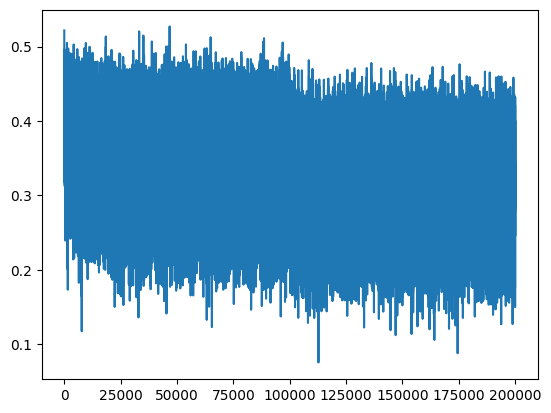

In [29]:
plt.plot(stepi, lossi);

In [30]:
@torch.no_grad() # Decorator, disables gradient tracking (no "book-keeping" on torch's side)
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]    # That's a switch (never seen it like this, neat!)
    
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # Concatenate into (N, block_size * n_embd)
    
    h = torch.tanh(embcat @ W1 + b1)    # (N, n_hidden)
    logits = h @ W2 + b2                # (N, vocab_size)
    loss = F.cross_entropy(logits, y)   # Loss function
    
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.070401430130005
val 2.1310105323791504


In [31]:
# Sample from the model
g = torch.Generator(device=device).manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # Forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      # Sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # Shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # As soon as we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # Decode and print the generated word

brentry.
ezek.
demarishanna.
drander.
diden.
murhihami.
chrat.
adge.
wylton.
dmer.
taylynne.
carsh.
taty.
kengeldyn.
daz.
raan.
jullana.
dorge.
dre.
imahi.


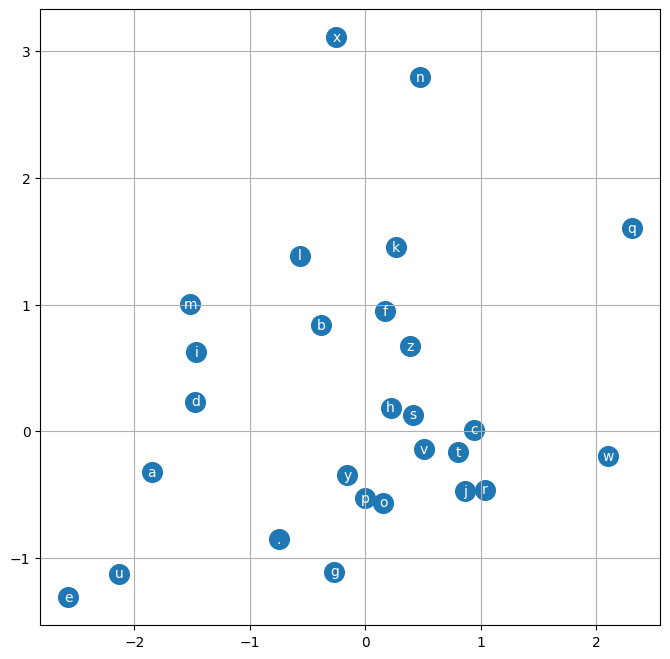

In [32]:
#Let's see if the training affected these embeddings in a meaningful way:
plt.figure(figsize=(8,8))
#plt.scatter(C[:,0].data, C[:,1].data, s=200) - if already on CPU, this is fine, but if on GPU, we need to detach and move to CPU before converting to numpy
plt.scatter(C[:,0].detach().cpu().numpy(), C[:,1].detach().cpu().numpy(), s=200) #GPU to CPU, detach from the graph, convert to numpy
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

In [71]:
C[0,8].item()

0.25090938806533813